In [2]:
"""
2D Parameter Sweep: Amplitude and gamma (alternating Ki scaling) using Finite Element
Sweeps over excitation amplitude A and gamma; keeps K_c fixed (vector)
"""

import sys, json, itertools, hashlib
import numpy as np
from numpy import pi
from pathlib import Path
from datetime import datetime
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

# Add project root to path
project_root = Path.cwd().resolve().parents[2]
sys.path.append(str(project_root))

from Modeling.models.beam_properties import PiezoBeamParams
from Modeling.models.FE1 import PiezoBeamFE, solve_newmark


In [ ]:
# ======= Save figures and data =======
sim_dat_dir = Path(__file__).parent / 'sim_dat'
sim_dat_dir.mkdir(parents=True, exist_ok=True)

fig_name = f'FE_2D_sweep_amp_gamma_Kp={K_p:.3f}_Ki={ki_nom:.0f}.png'
npz_filename = f'FE_2D_sweep_amp_gamma_Kp={K_p:.3f}_Ki={ki_nom:.0f}_Kc={kc_abs0:.2e}_{kc_hash}.npz'
# ======= Sweep Parameters =======
ki_nom = 1800.0
K_p = 0.03
R_c = 1e3
t_end = 1.0
f0 = 1000
f1 = 3000
dt = 1 / f1 / 50

# Amplitude and gamma lists
amp_list = np.linspace(5, 50, 8)           # V
gamma_list = np.linspace(0.0, 0.8, 5)      # dimensionless

# Fixed alternating K_c vector (update if needed)
kc0 = 6e10
K_c = np.array([kc0, -kc0] * 15)
Kc0_list = [  2e10, 3e10, 4e10, 5e10, 6e10]  # K_c (Duffing) sweep
Kc_list = np.array([[kc0, -kc0]*15  for kc0 in Kc0_list])
print(f"Amplitude sweep: {amp_list}")
print(f"Gamma sweep: {gamma_list}")
print(f"Total simulations: {len(amp_list) * len(gamma_list)}")

# FE model setup
params_fe = PiezoBeamParams(hp=0.252e-3, hs=0.51e-3, d31=-1.48e-10, eps_r=1700)
params_fe.zeta_p = 0.0151 * 8
params_fe.zeta_q = 0.0392 * 10
fe_params = params_fe  # pass by value to workers

def make_v_exc(A, f0, f1, t_end):
    def v_exc(t_var, A_exc=A, f0=f0, f1=f1, t_end=t_end):
        return A_exc * np.sin(2 * np.pi * (f0 + t_var * (f1 - f0) / t_end) * t_var)
    return v_exc

# ======= Single simulation runner =======
def run_single_simulation_amp_gamma(amp, gamma, K_p, ki_nom, K_c_vec, dt, t_end, f0, f1, fe_params):
    try:
        print(f"  Amp = {amp:.1f} V, gamma = {gamma:.3f}")
        # Build alternating Ki vector for this gamma
        ki0 = (1 - gamma) * ki_nom
        ki1 = (1 + gamma) * ki_nom
        K_i_vec = np.array([ki0, ki1] * 15 + [ki0])

        fe_local = PiezoBeamFE(fe_params)  # safe per-worker instance
        v_exc = make_v_exc(amp, f0, f1, t_end)
        ode = fe_local.build_ode_system(
            j_exc=30,
            K_c=K_c_vec,
            K_i=K_i_vec,
            K_p=K_p,
            R_c=R_c,
            v_exc=v_exc
        )

        result = solve_newmark(
            ode=ode,
            dt=dt,
            t_end=t_end,
            beta=0.25,
            gamma=0.5,
            newton_tol=1e-8,
            newton_maxiter=8,
            x0=np.zeros(ode.M.shape[0]),
            x_dot0=np.zeros(ode.M.shape[0]),
            do_spectral=True
        )

        return {
            "status": "ok",
            "result": {
                "amp": amp,
                "gamma": gamma,
                "K_i_vec": K_i_vec,
                "K_c_vec": np.asarray(K_c_vec),
                "t": result["t"],
                "u": result["u"],
                "u_dot": result["u_dot"],
                "u_ddot": result["u_ddot"],
                "q": result["q"],
                "v": result["v"],
                "freq": result["spectral"]["freq"],
                "FRF": result["spectral"]["FRF"],
                "spectrum": result["spectral"],
            },
        }
    except Exception as e:
        return {
            "status": "failed",
            "amp": amp,
            "gamma": gamma,
            "error": str(e),
            "exception_type": type(e).__name__,
        }

# ======= Run 2D sweep in parallel =======
print("Running 2D sweep (amp, gamma) in parallel...")
param_pairs = list(itertools.product(amp_list, gamma_list))

all_results = Parallel(n_jobs=16, verbose=10)(
    delayed(run_single_simulation_amp_gamma)(
        amp, gamma, K_p, ki_nom, K_c, dt, t_end, f0, f1, fe_params
    )
    for amp, gamma in param_pairs
)

# ======= Separate successes and failures =======
sim_results, failed_sims = [], []
for res in all_results:
    if res["status"] == "ok":
        sim_results.append(res["result"])
    else:
        failed_sims.append({
            "amp": res["amp"],
            "gamma": res["gamma"],
            "exception": res.get("exception_type", "Unknown"),
            "message": res["error"],
        })

print(f"\n{'='*70}")
print("SWEEP STATUS:")
print(f"  Total simulations: {len(all_results)}")
print(f"  Successful: {len(sim_results)}")
print(f"  Failed: {len(failed_sims)}")
print(f"{'='*70}\n")

if failed_sims:
    print("FAILED SIMULATIONS:")
    print("-" * 70)
    for fail in failed_sims:
        print(f"  Amp={fail['amp']:.1f}V, gamma={fail['gamma']:.3f}: {fail['exception']}")
        print(f"    → {fail['message']}")
    print("-" * 70 + "\n")

# ======= Organize results by gamma =======
results_by_gamma = {}
gamma_catalog = []

for res in sim_results:
    gamma = res["gamma"]
    if gamma not in results_by_gamma:
        results_by_gamma[gamma] = {
            "gamma": gamma,
            "amps": [],
            "FRFs": [],
            "time_histories": [],
            "freq": None,
            "t": None,
            "K_i_vec": res["K_i_vec"],
            "K_c_vec": res["K_c_vec"],
        }
        gamma_catalog.append(gamma)

    results_by_gamma[gamma]["amps"].append(res["amp"])
    results_by_gamma[gamma]["FRFs"].append(res["FRF"])
    results_by_gamma[gamma]["time_histories"].append({
        "amp": res["amp"],
        "t": res["t"],
        "u": res["u"],
        "u_dot": res["u_dot"],
        "u_ddot": res["u_ddot"],
        "q": res["q"],
        "v": res["v"],
    })

    if results_by_gamma[gamma]["freq"] is None:
        results_by_gamma[gamma]["freq"] = res["freq"]
        results_by_gamma[gamma]["t"] = res["t"]

# Sort gammas
gamma_order = sorted(gamma_catalog)

# ======= Plot FRFs for each gamma =======
fig, axes = plt.subplots(len(gamma_order), 1, figsize=(10, 4 * len(gamma_order)))
if len(gamma_order) == 1:
    axes = [axes]

for idx, gamma in enumerate(gamma_order):
    ax = axes[idx]
    data = results_by_gamma[gamma]
    cmap = plt.cm.viridis
    colors = cmap(np.linspace(0, 1, len(data["amps"])))

    for i, (amp, FRF) in enumerate(zip(data["amps"], data["FRFs"])):
        ax.semilogy(data["freq"], FRF, '.-', color=colors[i], linewidth=2,
                    label=f"A = {amp:.1f} V")

    ax.set_xlim([1300, 3000])
    ax.set_ylim([3e-5, 6e-4])
    ax.grid(True, alpha=0.4)
    ax.legend(loc='best', fontsize=8)
    ax.set_xlabel("Frequency [Hz]")
    ax.set_ylabel("FRF Magnitude")
    ax.set_title(f"FE: Amplitude Sweep at gamma = {gamma:.3f}")

plt.tight_layout()


plt.savefig(sim_dat_dir / fig_name, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {sim_dat_dir / fig_name}")
plt.close(fig)

def short_hash(arr):
    arr_np = np.asarray(arr, dtype=float)
    return hashlib.sha1(arr_np.tobytes()).hexdigest()[:8]

kc_abs0 = float(np.abs(np.asarray(K_c, dtype=float)[0]))
kc_hash = short_hash(K_c)



np.savez(sim_dat_dir / npz_filename,
         amp_list=amp_list,
         gamma_list=np.array(gamma_order),
         K_p=K_p,
         ki_nom=ki_nom,
         K_c=np.asarray(K_c, dtype=float),
         K_c_abs0=kc_abs0,
         K_c_hash=kc_hash,
         R_c=R_c,
         t_end=t_end,
         f0=f0,
         f1=f1,
         dt=dt,
         results_by_gamma=results_by_gamma,
         failed_sims=np.array(failed_sims, dtype=object))

print(f"Results saved to: {sim_dat_dir / npz_filename}")

# ======= Save error log if needed =======
if failed_sims:
    error_log = {
        "timestamp": datetime.now().isoformat(),
        "total_simulations": len(all_results),
        "successful_simulations": len(sim_results),
        "failed_simulations": len(failed_sims),
        "failed_cases": failed_sims,
        "sweep_parameters": {
            "K_p": K_p,
            "ki_nom": ki_nom,
            "K_c_abs0": kc_abs0,
            "f0": f0,
            "f1": f1,
            "dt": dt,
            "t_end": t_end
        }
    }
    err_path = sim_dat_dir / f'FE_2D_sweep_amp_gamma_errors_Kp={K_p:.3f}_Ki={ki_nom:.0f}_Kc={kc_abs0:.2e}_{kc_hash}.json'
    with open(err_path, 'w') as f:
        json.dump(error_log, f, indent=2)
    print(f"Error log saved to: {err_path}")

print("\n" + "="*70)
print("2D FE SWEEP (amp, gamma) COMPLETE")
print("="*70)

# Plot the saved data


In [4]:
np.set_printoptions(precision=3, suppress=True)
for key in data.keys():
    if not key == "results_by_gamma":
        print(key, ":", data[key])
for key in data["results_by_gamma"].keys():
    print(key)

amp_list : [ 5.    11.429 17.857 24.286 30.714 37.143 43.571 50.   ]
gamma_list : [0.  0.2 0.4 0.6 0.8]
K_p : 0.03
ki_nom : 1800.0
K_c : [ 6.e+10 -6.e+10  6.e+10 -6.e+10  6.e+10 -6.e+10  6.e+10 -6.e+10  6.e+10
 -6.e+10  6.e+10 -6.e+10  6.e+10 -6.e+10  6.e+10 -6.e+10  6.e+10 -6.e+10
  6.e+10 -6.e+10  6.e+10 -6.e+10  6.e+10 -6.e+10  6.e+10 -6.e+10  6.e+10
 -6.e+10  6.e+10 -6.e+10]
K_c_abs0 : 60000000000.0
K_c_hash : 5ac7f7dc
R_c : 1000.0
t_end : 1.0
f0 : 1000
f1 : 3000
dt : 6.666666666666667e-06
failed_sims : [{'amp': np.float64(37.142857142857146), 'gamma': np.float64(0.0), 'exception': 'RuntimeError', 'message': 'Newton did not converge at step 13051, residual = 1.7249531544248309'}
 {'amp': np.float64(37.142857142857146), 'gamma': np.float64(0.8), 'exception': 'RuntimeError', 'message': 'Newton did not converge at step 37610, residual = 2.3141123359042965'}
 {'amp': np.float64(43.57142857142857), 'gamma': np.float64(0.0), 'exception': 'RuntimeError', 'message': 'Newton did not converg

AttributeError: 'numpy.ndarray' object has no attribute 'keys'

In [12]:
# data["results_by_gamma"][gamma_list[0]].keys() 
gamma_list[0] 
# type(data["results_by_gamma"])
res.keys() 
res['K_i_vec']


array([ 360., 3240.,  360., 3240.,  360., 3240.,  360., 3240.,  360.,
       3240.,  360., 3240.,  360., 3240.,  360., 3240.,  360., 3240.,
        360., 3240.,  360., 3240.,  360., 3240.,  360., 3240.,  360.,
       3240.,  360., 3240.,  360.])

Loading: FE_2D_sweep_amp_gamma_Kp=0.030_Ki=1800_Kc=6.00e+10_5ac7f7dc.npz


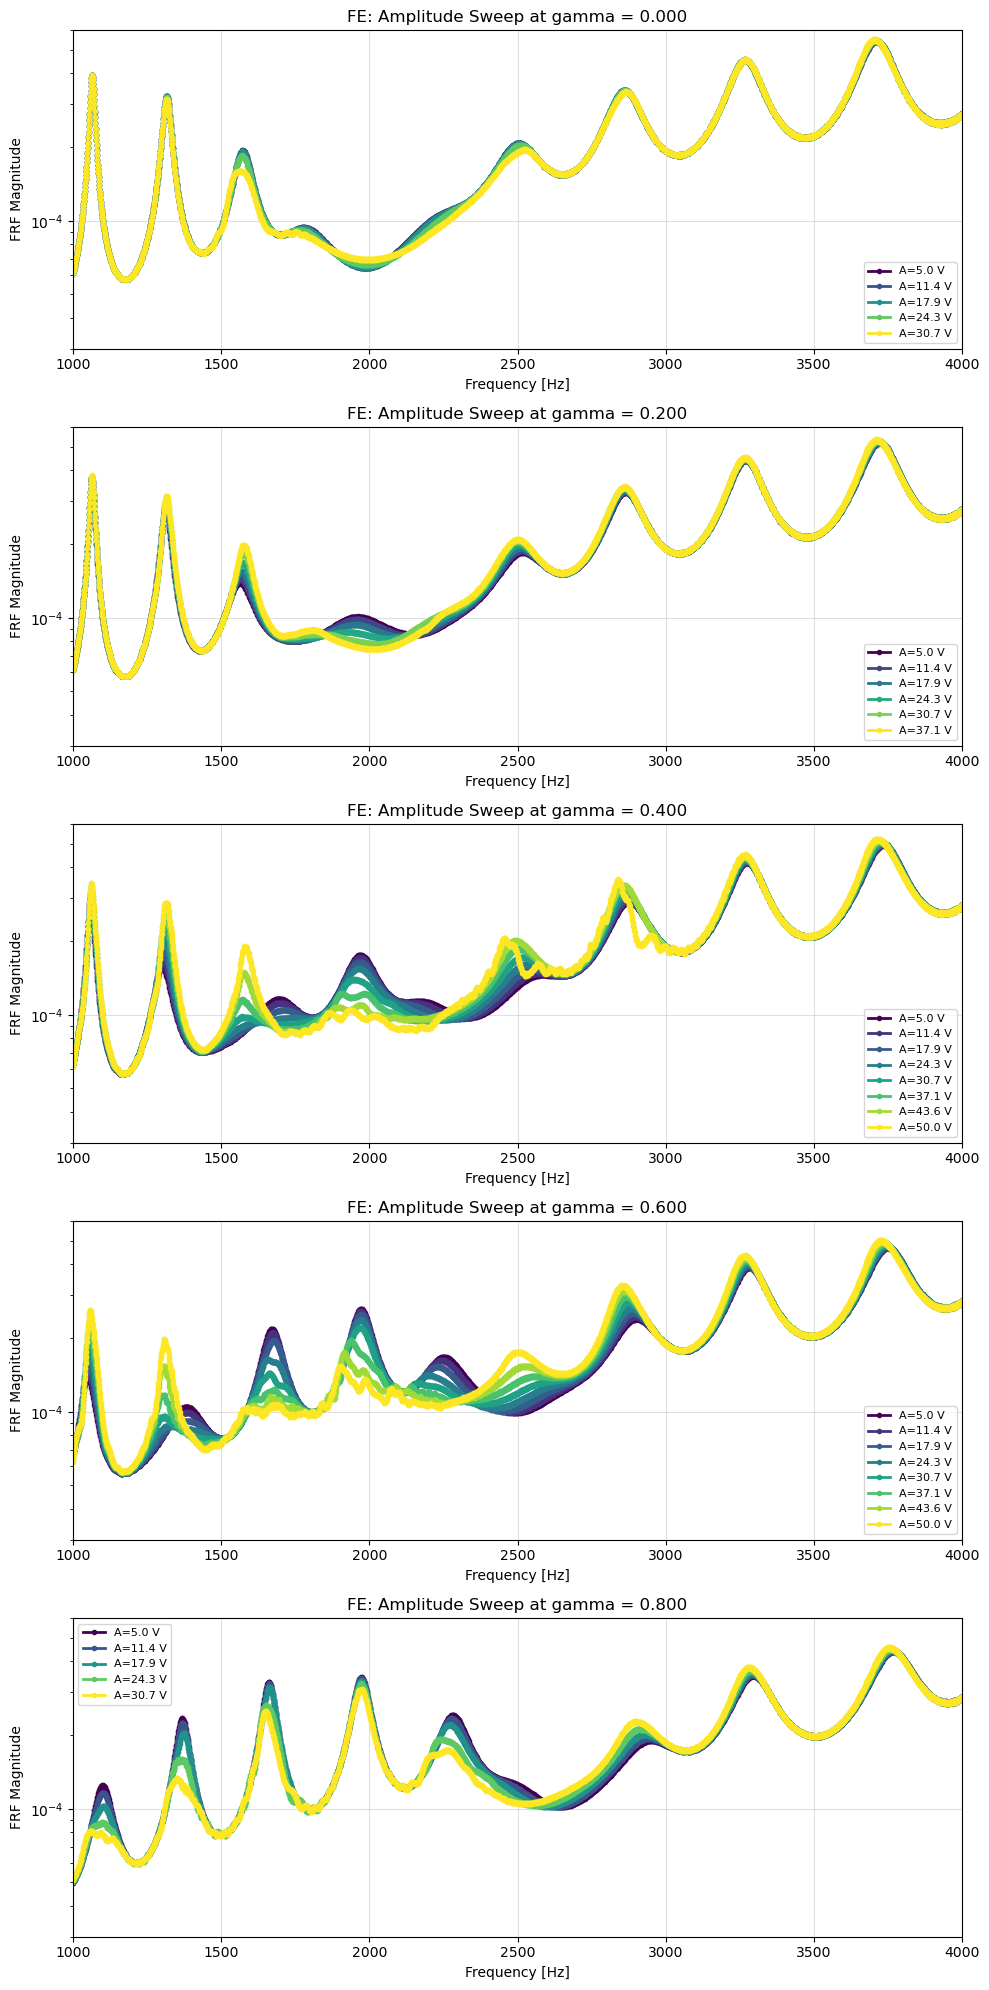

In [3]:
from pathlib import Path
npz_path = Path(r".\sim_dat\OLD\FE_2D_sweep_amp_gamma_Kp=0.030_Ki=1800_Kc=6.00e+10_5ac7f7dc.npz")
print(f"Loading: {Path(npz_path).name}")
data = np.load(npz_path, allow_pickle=True)

gamma_list = data["gamma_list"]
results_by_gamma = data["results_by_gamma"].item()

fig, axes = plt.subplots(len(gamma_list), 1, figsize=(10, 4 * len(gamma_list)))
if len(gamma_list) == 1:
    axes = [axes]

for ax, gamma in zip(axes, sorted(gamma_list)):
    res = results_by_gamma[gamma]
    freq = res["freq"]
    cmap = plt.cm.viridis
    colors = cmap(np.linspace(0, 1, len(res["amps"])))
    for i, (A, FRF) in enumerate(zip(res["amps"], res["FRFs"])):
        ax.semilogy(freq, FRF, ".-", color=colors[i], linewidth=2, label=f"A={A:.1f} V")
    ax.set_xlim([1000, 4000])
    ax.set_ylim([3e-5, 6e-4])
    ax.grid(True, alpha=0.4)
    ax.set_xlabel("Frequency [Hz]")
    ax.set_ylabel("FRF Magnitude")
    ax.set_title(f"FE: Amplitude Sweep at gamma = {gamma:.3f}")
    ax.legend(fontsize=8, loc="best")

plt.tight_layout()
plt.show()
# ...existing code...